In [85]:
import numpy as np
import matplotlib.pyplot as plt
from time import time
from center import center
from dahc import dahc
from hrc import hrc
from DAHD4freq_part_weight import DAHD4freq_part_weight
from DAHM4_ex import DAHM4_ex
from generate_data import x, xref1, xref2, xref3, xref4, N

## dahd4example
Full DAHD pipeline: spectral analysis, mode computation, and harmonic reconstruction.

This notebook ties together all DAHD components and reproduces the main result figures.

**Pipeline:**
1. Load and center synthetic data from `generate_data`.
2. Compute the DAHD spectrum via `DAHD4freq_part_weight`.
3. Compute space-time DAHMs via `DAHM4_ex`.
4. Plot the space-time DAHM eigenvector pairs (Ej, E'j) for the four target frequencies.
5. Reconstruct harmonic components via `dahc` + `hrc`.
6. Compute normalized RMSE and plot reconstructions vs. reference modes.

**Dependencies:** `center`, `dahc`, `hrc`, `DAHD4freq_part_weight`, `DAHM4_ex`, `generate_data`


In [86]:
# Center data
fpcs, _ = center(x)

In [87]:
W = int((fpcs.shape[0] + 1) / 2)   # maximum window length
W = 65
WW = 2 * W - 1
D = fpcs.shape[1]
NP = D      # maximum is D
NFE = W     # maximum is W

In [88]:
# wt = 'hann'
# wt = 'blackman'
# wt = 'hanning'
# wt = 'hamming'
# wt = 'bartlett'
wt = 'hamming'
# wt = 'none'

In [89]:
start = time()
fE2, VP, FEP = DAHD4freq_part_weight(fpcs, W, NFE, NP, wt)
print(f"Elapsed time: {time() - start:.4f} seconds")

0 >0:2 <0:4
1 >0:3 <0:3
2 >0:4 <0:2
3 >0:4 <0:2
4 >0:3 <0:3
5 >0:4 <0:2
6 >0:4 <0:2
7 >0:4 <0:2
8 >0:3 <0:3
9 >0:4 <0:2
10 >0:4 <0:2
11 >0:3 <0:3
12 >0:4 <0:2
13 >0:4 <0:2
14 >0:3 <0:3
15 >0:4 <0:2
16 >0:4 <0:2
17 >0:4 <0:2
18 >0:4 <0:2
19 >0:4 <0:2
20 >0:4 <0:2
21 >0:4 <0:2
22 >0:3 <0:3
23 >0:4 <0:2
24 >0:4 <0:2
25 >0:4 <0:2
26 >0:4 <0:2
27 >0:4 <0:2
28 >0:4 <0:2
29 >0:3 <0:3
30 >0:4 <0:2
31 >0:3 <0:3
32 >0:4 <0:2
33 >0:4 <0:2
34 >0:4 <0:2
35 >0:3 <0:3
36 >0:4 <0:2
37 >0:4 <0:2
38 >0:4 <0:2
39 >0:3 <0:3
40 >0:4 <0:2
41 >0:3 <0:3
42 >0:4 <0:2
43 >0:3 <0:3
44 >0:3 <0:3
45 >0:3 <0:3
46 >0:4 <0:2
47 >0:4 <0:2
48 >0:4 <0:2
49 >0:4 <0:2
50 >0:4 <0:2
51 >0:3 <0:3
52 >0:4 <0:2
53 >0:3 <0:3
54 >0:3 <0:3
55 >0:3 <0:3
56 >0:4 <0:2
57 >0:4 <0:2
58 >0:4 <0:2
59 >0:4 <0:2
60 >0:4 <0:2
61 >0:4 <0:2
62 >0:4 <0:2
63 >0:3 <0:3
64 >0:3 <0:3
Elapsed time: 0.8657 seconds


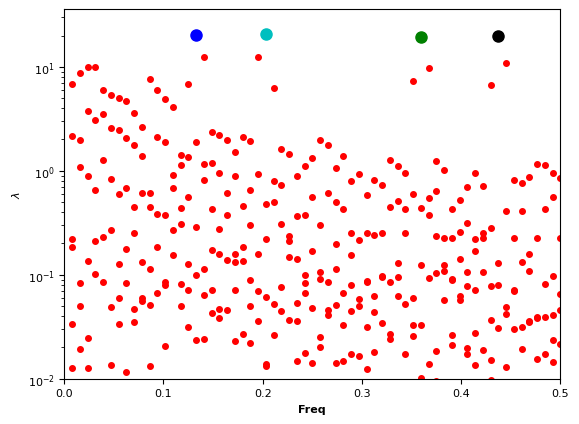

In [90]:
# DAHD spectrum
NP = 1
plt.figure()
plt.rcParams.update({'font.size': 16})
plt.semilogy(fE2[1:], np.abs(VP[:, 1:]).T, 'ro', markersize=4, markerfacecolor='r')
plt.semilogy(fE2[17], np.abs(VP[:NP, 17]), 'bo', markersize=8, markerfacecolor='b')
plt.semilogy(fE2[26], np.abs(VP[:NP, 26]), 'co', markersize=8, markerfacecolor='c')
plt.semilogy(fE2[46], np.abs(VP[:NP, 46]), 'go', markersize=8, markerfacecolor='g')
plt.semilogy(fE2[56], np.abs(VP[:NP, 56]), 'ko', markersize=8, markerfacecolor='k')
plt.ylabel(r'$\lambda$')
plt.xlim([0, 0.5])
plt.ylim(bottom=1e-2)
plt.xlabel('Freq')
plt.show()

In [91]:
# Compute DAHMs
EP = np.zeros(((2 * W - 1) * D, 2 * NP, NFE))
start = time()
for iff in range(NFE):
    ER = DAHM4_ex(FEP[:, :, iff], W, iff, 2 * NP)
    ERR = np.reshape(ER, ((2 * W - 1) * D, 2 * NP))
    EP[:, :, iff] = ERR
print(f"Elapsed time: {time() - start:.4f} seconds")

Elapsed time: 0.0295 seconds


/var/folders/xl/xr37p5hn1vjf5bvdbd5hm8q80000gn/T/ipykernel_28171/889787550.py:7: ComplexWarning: Casting complex values to real discards the imaginary part
  EP[:, :, iff] = ERR


In [92]:
tt = ['(a) f_1', '(b) f_2', '(c) f_3', '(d) f_4']
ff = [17, 26, 46, 56]   # 0-indexed (MATLAB: 18, 27, 47, 57)

In [93]:
fig = plt.figure(figsize=(20 / 2.54, 40 / 2.54), dpi=100)
plt.rcParams.update({
    'axes.labelweight': 'bold',
    'axes.titleweight': 'bold',
    'axes.labelsize': 8,
    'axes.titlesize': 8,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
})

<Figure size 787.402x1574.8 with 0 Axes>

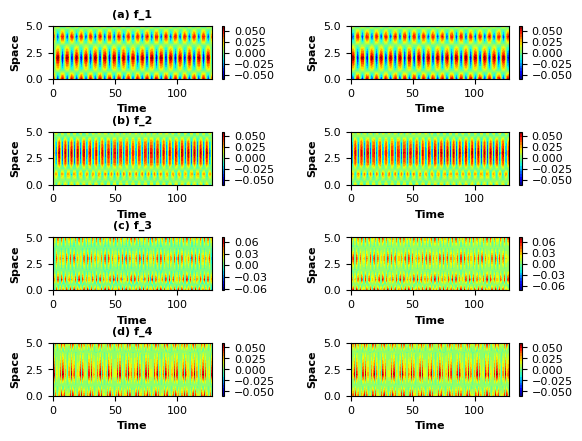

In [94]:
kk = 0
for pos in range(4):
    for K in range(2):
        kk += 1
        plt.subplot(4, 2, kk)
        cf = plt.contourf(
            np.reshape(EP[:, K, ff[pos]], (WW, 6)).T,
            20, cmap='jet'
        )
        cbar = plt.colorbar(cf)
        cbar.locator = plt.MaxNLocator(nbins=5)   # fewer tick labels
        cbar.update_ticks()
        if K == 0:
            plt.title(tt[pos])
        plt.xlabel('Time')
        plt.ylabel('Space')

plt.subplots_adjust(hspace=1.0, wspace=0.5)

In [95]:
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

In [96]:
# Reconstruction
# Indices of frequencies of the harmonic modes for maximum window length
ifff = [17, 26, 46, 56]   # 0-indexed (MATLAB: 18, 27, 47, 57)
NE = fpcs.shape[0]
PCF = np.zeros((NE, D, len(ifff)))
AF = np.zeros((N - (2 * W - 1) + 1, 2, len(ifff)))
NPP = 1     # reconstruct only with modes at spectral peak

In [97]:
for i in range(len(ifff)):
    iff = ifff[i]
    tmp = np.squeeze(EP[:, :2 * NPP, iff])
    A = dahc(fpcs, tmp)
    AF[:, :, i] = A
    PCF[:, :, i] = hrc(A, tmp, fpcs.shape[1], np.arange(2 * NPP))

In [98]:
R1 = np.squeeze(PCF[:, :, 0])
R2 = np.squeeze(PCF[:, :, 1])
R3 = np.squeeze(PCF[:, :, 2])
R4 = np.squeeze(PCF[:, :, 3])

In [99]:
# Normalized RMSE of reconstruction
print('Normalized RMSE of reconstruction:')
print(np.sum(np.sum((xref1 - R1) ** 2, axis=1)) / np.sum(np.sum(xref1 ** 2, axis=1)))
print(np.sum(np.sum((xref2 - R2) ** 2, axis=1)) / np.sum(np.sum(xref2 ** 2, axis=1)))
print(np.sum(np.sum((xref3 - R3) ** 2, axis=1)) / np.sum(np.sum(xref3 ** 2, axis=1)))
print(np.sum(np.sum((xref4 - R4) ** 2, axis=1)) / np.sum(np.sum(xref4 ** 2, axis=1)))

Normalized RMSE of reconstruction:
0.5922982119754014
0.6577217224541291
0.11338330501938033
0.422582808714836


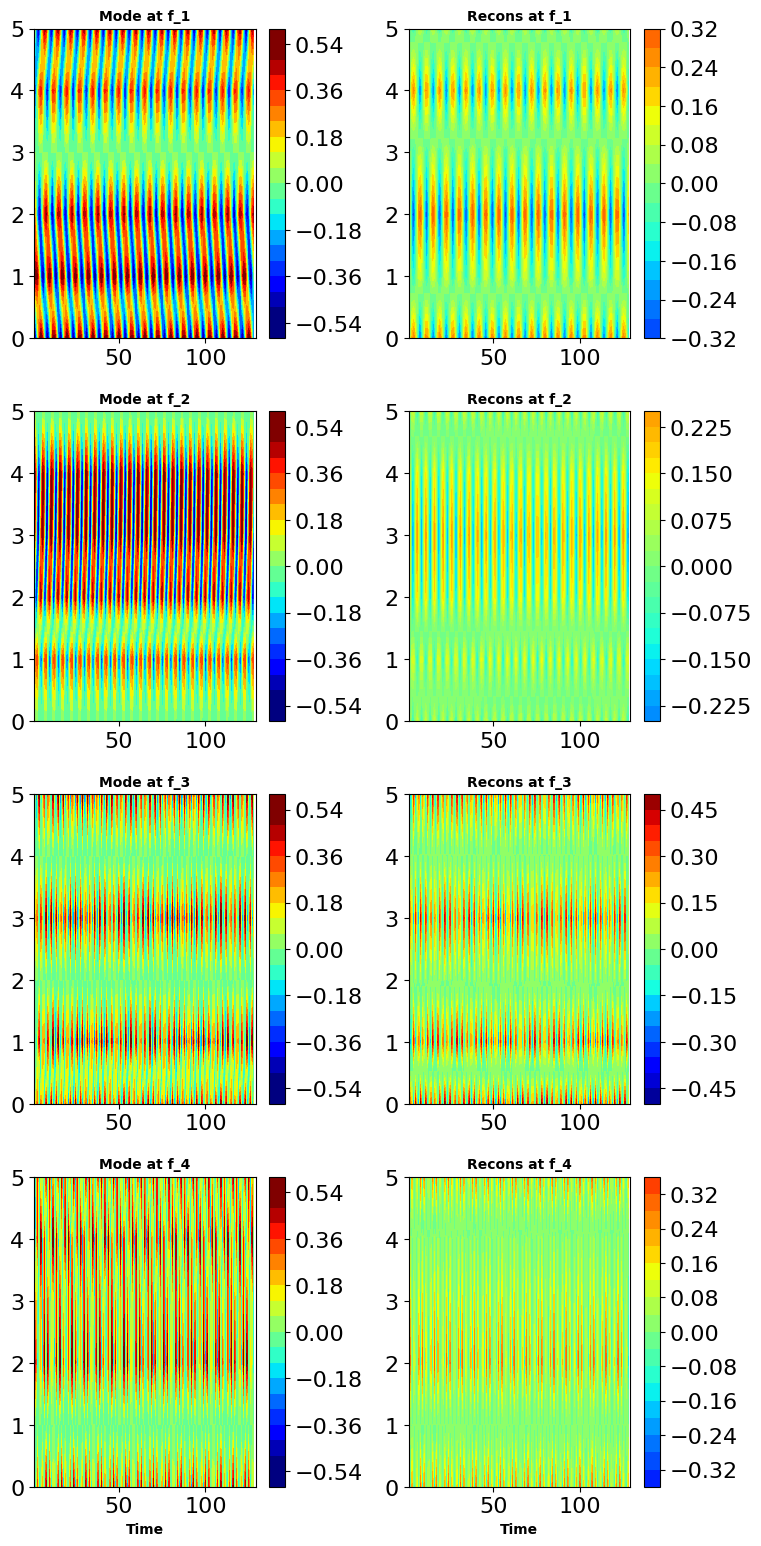

In [100]:
# Plot reconstructed harmonic components (see plothrcmodes.py)
exec(open('plothrcmodes.py').read())